# PlantCLEF 2015 LeafScan S-CNN Training

Strict workflow for reproducing the paper protocol. Use the Google Drive LeafScan archive first, then smoke-train, train both S-CNN stages, and evaluate the full species ranking.


## 1. Runtime Check

Select `Runtime -> Change runtime type -> GPU` before running training cells.


In [3]:
import torch

print('CUDA:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


CUDA: True
Device: Tesla T4


## 2. Clone Or Update Project


In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import yaml

PROJECT_DIR = Path('/content/diploma')
REPO_URL = 'https://github.com/robodanill/diploma.git'
BRANCH = 'robodanill/main'


def clone_project():
    os.chdir('/content')
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    subprocess.run(['git', 'clone', '-b', BRANCH, REPO_URL, str(PROJECT_DIR)], check=True)


def pull_project() -> bool:
    if not (PROJECT_DIR / '.git').exists():
        return False
    result = subprocess.run(['git', 'pull', '--ff-only'], cwd=PROJECT_DIR)
    return result.returncode == 0


if PROJECT_DIR.exists():
    print(f'Trying to update existing project: {PROJECT_DIR}')
    if not pull_project():
        print('Pull failed or project is not a git repository; cloning a fresh copy.')
        clone_project()
else:
    print(f'Project not found at {PROJECT_DIR}; cloning a fresh copy.')
    clone_project()

os.chdir(PROJECT_DIR)
subprocess.run(['python', '-m', 'pip', 'install', '-e', '.[ml]'], check=True)

commit = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], cwd=PROJECT_DIR, text=True).strip()
print(f'Project commit: {commit}')

smoke_config = yaml.safe_load((PROJECT_DIR / 'configs/leafscan_smoke_training.yaml').read_text())
print('Smoke evaluation enabled:', smoke_config['evaluation']['enabled'])


Project not found at /content/diploma; cloning a fresh copy.
Project commit: e33c2c9
Smoke evaluation enabled: True


## 3. Mount Google Drive, Unpack LeafScan Dataset, And Create Split

Expected archive paths: `/content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz` and `/content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz`. The strict paper run builds `leafscan_paper60_metadata.csv` from the 60 official test species; `leafscan_metadata_split.csv` is created only for smoke validation.


In [2]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%%bash
set -euo pipefail
trap 'echo "FAILED at line $LINENO: $BASH_COMMAND" >&2' ERR
export PYTHONUNBUFFERED=1
cd /content/diploma
ARCHIVE=/content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz
TEST_ARCHIVE=/content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz
echo "checking required archives"
ls -lh /content/drive/MyDrive/PlantCLEF2015*.tar.gz 2>/dev/null || true
if [ ! -f "$ARCHIVE" ]; then
  echo "Missing required LeafScan training archive: $ARCHIVE" >&2
  echo "Existing PlantCLEF archives in Google Drive:" >&2
  find /content/drive/MyDrive -maxdepth 1 -type f -iname 'PlantCLEF2015*.tar.gz' -printf '  %f\n' >&2 || true
  echo "Build it from the full PlantCLEF training package with:" >&2
  echo "  python scripts/build_plantclef_content_bundle.py --source-root /path/to/PlantCLEF2015/train --output $ARCHIVE --content LeafScan" >&2
  exit 2
fi
rm -rf data/plantclef2015
mkdir -p data/plantclef2015
echo "extracting training archive: $ARCHIVE"
tar -xzf "$ARCHIVE" -C data/plantclef2015
if [ ! -f data/plantclef2015/leafscan/metadata.csv ]; then
  echo "Training archive extracted, but leafscan/metadata.csv was not found." >&2
  echo "Archive top-level sample:" >&2
  tar -tzf "$ARCHIVE" | head -40 >&2
  exit 4
fi
cp data/plantclef2015/leafscan/metadata.csv data/plantclef2015/leafscan_metadata.csv
if [ ! -f "$TEST_ARCHIVE" ]; then
  echo "Missing required LeafScan test archive: $TEST_ARCHIVE" >&2
  echo "Run notebooks/plantclef_colab_test_data.ipynb first; strict paper training needs the official 60 test species list." >&2
  exit 3
fi
rm -rf data/plantclef2015/test_leafscan
mkdir -p data/plantclef2015/test_leafscan
echo "extracting test archive: $TEST_ARCHIVE"
tar -xzf "$TEST_ARCHIVE" -C data/plantclef2015/test_leafscan
if [ ! -f data/plantclef2015/test_leafscan/leafscan/metadata.csv ]; then
  echo "Test archive extracted, but leafscan/metadata.csv was not found." >&2
  echo "Archive top-level sample:" >&2
  tar -tzf "$TEST_ARCHIVE" | head -40 >&2
  exit 5
fi
cp data/plantclef2015/test_leafscan/leafscan/metadata.csv data/plantclef2015/test_leafscan_metadata.csv
echo "test leafscan archive extracted"
plant-classifier-split-metadata \
  --metadata data/plantclef2015/leafscan_metadata.csv \
  --dataset-root data/plantclef2015/leafscan \
  --output data/plantclef2015/leafscan_metadata_split.csv \
  --train-ratio 0.70 \
  --val-ratio 0.15 \
  --test-ratio 0.15
wc -l data/plantclef2015/leafscan_metadata_split.csv
python - <<'PY2'
import csv
from collections import Counter, defaultdict
from pathlib import Path
from PIL import Image
with open('data/plantclef2015/leafscan_metadata.csv', newline='', encoding='utf-8') as file:
    source_rows = list(csv.DictReader(file))
print('leafscan source rows:', len(source_rows))
print('leafscan source content:', Counter(row.get('content', '') for row in source_rows))
print('leafscan source genera:', len({row['genus'] for row in source_rows}))
print('leafscan source species:', len({row['species'] for row in source_rows}))
if len(source_rows) != 12605:
    raise RuntimeError(f'Expected 12605 PlantCLEF train LeafScan rows, got {len(source_rows)}')
with open('data/plantclef2015/leafscan_metadata_split.csv', newline='', encoding='utf-8') as file:
    rows = list(csv.DictReader(file))
print('smoke split:', Counter(row['split'] for row in rows))

with open('data/plantclef2015/test_leafscan_metadata.csv', newline='', encoding='utf-8') as file:
    test_rows = list(csv.DictReader(file))
test_species = {row['species'] for row in test_rows}
paper60_rows = [row for row in source_rows if row['species'] in test_species]
with open('data/plantclef2015/leafscan_paper60_metadata.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=source_rows[0].keys())
    writer.writeheader()
    writer.writerows(paper60_rows)
paper60_genera = {row['genus'] for row in paper60_rows}
paper60_species = {row['species'] for row in paper60_rows}
paper60_species_by_genus = defaultdict(set)
test_species_by_genus = defaultdict(set)
for row in paper60_rows:
    paper60_species_by_genus[row['genus']].add(row['species'])
for row in test_rows:
    test_species_by_genus[row['genus']].add(row['species'])
paper60_species_per_genus = {genus: len(species) for genus, species in paper60_species_by_genus.items()}
test_species_per_genus = {genus: len(species) for genus, species in test_species_by_genus.items()}
print('paper60 train rows:', len(paper60_rows))
print('paper60 train genera:', len(paper60_genera))
print('paper60 train species:', len(paper60_species))
print('paper60 max species per genus:', max(paper60_species_per_genus.values()))
print('paper60 genera with >6 species:', sorted(g for g, count in paper60_species_per_genus.items() if count > 6))
print('paper60 test rows:', len(test_rows))
print('paper60 test genera:', len({row['genus'] for row in test_rows}))
print('paper60 test species:', len(test_species))
print('paper60 test max species per genus:', max(test_species_per_genus.values()))
print('paper60 test genera with >6 species:', sorted(g for g, count in test_species_per_genus.items() if count > 6))
if len(paper60_rows) != 6527:
    print('warning: paper text/OCR suggests 6527 train rows, but this archive gives', len(paper60_rows))
if len(test_rows) != 221 or len({row['genus'] for row in test_rows}) != 43 or len(test_species) != 60:
    raise RuntimeError('Expected PlantCLEF paper test subset 221 rows / 43 genera / 60 species')
source_species = {row['species'] for row in source_rows}
missing_in_train = sorted(test_species - source_species)
if missing_in_train:
    print('paper60 missing test species in train:', missing_in_train[:20])
    raise RuntimeError(f'Cannot build paper60 train subset: {len(missing_in_train)} test species are missing from train metadata')
train_count_by_species = Counter(row['species'] for row in paper60_rows)
underfilled_species = sorted(species for species in test_species if train_count_by_species[species] < 6)
if underfilled_species:
    print('paper60 species with fewer than 6 train images:', underfilled_species[:20])
    rows_by_species = defaultdict(list)
    for row in paper60_rows:
        rows_by_species[row['species']].append(row)
    augmented_dir = Path('data/plantclef2015/leafscan/augmented')
    augmented_dir.mkdir(parents=True, exist_ok=True)
    leafscan_root = Path('data/plantclef2015/leafscan')
    angles = [180, 90, 270, 15, -15]
    augmented_rows = []
    for species in underfilled_species:
        species_rows = rows_by_species[species]
        if not species_rows:
            raise RuntimeError(f'Cannot augment {species}: no train rows found')
        needed = 6 - len(species_rows)
        for index in range(needed):
            base_row = species_rows[index % len(species_rows)]
            source_path = Path(base_row['image_path'])
            if not source_path.is_absolute():
                source_path = leafscan_root / source_path
            angle = angles[index % len(angles)]
            output_name = f"{source_path.stem}_aug_rot{angle}_{index + 1}.jpg".replace('-', 'm')
            output_path = augmented_dir / output_name
            with Image.open(source_path) as image:
                image.convert('RGB').rotate(angle, expand=True, fillcolor=(255, 255, 255)).save(output_path, quality=95)
            augmented_row = dict(base_row)
            augmented_row['image_path'] = str(output_path.relative_to(leafscan_root))
            if 'source_xml' in augmented_row:
                augmented_row['source_xml'] = f"{augmented_row['source_xml']}#aug_rot{angle}"
            augmented_rows.append(augmented_row)
            print('augmented paper60 row:', species, 'from', source_path.name, '->', augmented_row['image_path'])
    paper60_rows.extend(augmented_rows)
    with open('data/plantclef2015/leafscan_paper60_metadata.csv', 'w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=source_rows[0].keys())
        writer.writeheader()
        writer.writerows(paper60_rows)
    print('paper60 augmented rows added:', len(augmented_rows))
train_count_by_species = Counter(row['species'] for row in paper60_rows)
underfilled_species = sorted(species for species in test_species if train_count_by_species[species] < 6)
if underfilled_species:
    raise RuntimeError(f'Cannot build 6-shot paper subset after augmentation: {len(underfilled_species)} species have fewer than 6 train images')
print('paper60 six-shot training rows:', 6 * len(test_species))
PY2


checking required archives
-rw------- 1 root root 2.5G May  2 16:27 /content/drive/MyDrive/PlantCLEF2015_leaf_only.tar.gz
-rw------- 1 root root 1.2G May  3 18:06 /content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz
-rw------- 1 root root  22M May  3 16:51 /content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz
-rw------- 1 root root    0 May  3 16:41 /content/drive/MyDrive/PlantCLEF2015TestDataWithAnnotations.tar.gz
extracting training archive: /content/drive/MyDrive/PlantCLEF2015_leafscan_only.tar.gz
extracting test archive: /content/drive/MyDrive/PlantCLEF2015_leafscan_test.tar.gz
test leafscan archive extracted
saved 12605 rows to data/plantclef2015/leafscan_metadata_split.csv
split counts: {'train': 8754, 'val': 1827, 'test': 2024}
12606 data/plantclef2015/leafscan_metadata_split.csv
leafscan source rows: 12605
leafscan source content: Counter({'LeafScan': 12605})
leafscan source genera: 241
leafscan source species: 351
smoke split: Counter({'train': 8754, 'test': 2024, 'va

## 4. Smoke Train `S-CNN (A)` Genus

This is only a pipeline check on a small subset. It also runs genus retrieval evaluation after the epoch.


In [16]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/leafscan_smoke_training.yaml   --stage genus   --output checkpoints/smoke_scnn_genus_vgg16.pt


using subset: 110 images from 20 species
training split=train records=110
building model backbone=vgg16 pretrained=True
model ready
genus eval enabled: source=split references=22 queries=22 top_k=(1, 3, 5) score_mode=comparator
training device=cuda
epoch=1 sampled_pairs=200 sampling=label_uniform batch_size=16 hard_negative_ratio=0.00 targeted_negative_ratio=0.00 targeted_negative_pairs=0 device=cuda
epoch=1 batch=5/13 running_loss=0.7500
epoch=1 batch=10/13 running_loss=0.7140
epoch=1 batch=13/13 running_loss=0.7269
epoch=1 eval=starting
epoch=1 loss=0.7269 best_loss=0.7269 top1_genus_accuracy=0.227 top3_genus_accuracy=0.500 top5_genus_accuracy=0.591 val_pair_loss=0.5688 score_mode=comparator best_top5=0.591 eval=13/22 time=18.2s best


## 5. Smoke Evaluate `S-CNN (A)` On Validation Split


In [17]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.eval_genus_cli   --config configs/leafscan_smoke_training.yaml   --checkpoint checkpoints/smoke_scnn_genus_vgg16.pt   --max-species 40   --references-per-genus 2   --queries-per-genus 2   --top-k 5


using reference subset: 113 images from 20 species
references=22 queries=22 top_k=[5] score_mode=comparator reference_seed=None
top5_genus_accuracy=0.727 (16/22)
query genus distribution: {'Acer': 2, 'Aesculus': 2, 'Ailanthus': 2, 'Albizia': 2, 'Alcea': 2, 'Alnus': 2, 'Althaea': 2, 'Anemone': 2, 'Anthriscus': 2, 'Antirrhinum': 2}
reference genus distribution: {'Acer': 2, 'Aesculus': 2, 'Ailanthus': 2, 'Albizia': 2, 'Alcea': 2, 'Alnus': 2, 'Althaea': 2, 'Anemone': 2, 'Anthriscus': 2, 'Antirrhinum': 2}
reference pool species per genus: {'Acer': 8, 'Alnus': 3, 'Aesculus': 1, 'Ailanthus': 1, 'Albizia': 1, 'Alcea': 1, 'Althaea': 1, 'Anemone': 1, 'Anthriscus': 1, 'Antirrhinum': 1}
genus reference species coverage: {'Acer': '1/8', 'Alnus': '1/3', 'Aesculus': '1/1', 'Ailanthus': '1/1', 'Albizia': '1/1', 'Alcea': '1/1', 'Althaea': '1/1', 'Anemone': '1/1', 'Anthriscus': '1/1', 'Antirrhinum': '1/1'}


## 6. Full VGG16 Train `S-CNN (A)` Genus

Trains the global-view genus model with `configs/leafscan_paper60_training.yaml` and saves `scnn_genus_vgg16.pt` plus `scnn_genus_vgg16_best.pt`.


In [9]:
!export PYTHONUNBUFFERED=1
!cd /content/diploma
!python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_training.yaml   --stage genus   --output checkpoints/scnn_genus_vgg16.pt


using subset: 360 images from 60 species
training split=train records=360
building model backbone=vgg16 pretrained=True
model ready
genus eval enabled: source=train_subset references=86 queries=86 top_k=(5, 15) score_mode=l1
training device=cuda
epoch=1 sampled_pairs=1000 sampling=pair_uniform batch_size=32 hard_negative_ratio=0.00 targeted_negative_ratio=0.05 targeted_negative_pairs=10 device=cuda
epoch=1 batch=5/32 running_loss=0.7331
epoch=1 batch=10/32 running_loss=0.7214
epoch=1 batch=15/32 running_loss=0.7174
epoch=1 batch=20/32 running_loss=0.7141
epoch=1 batch=25/32 running_loss=0.7109
epoch=1 batch=30/32 running_loss=0.7007
epoch=1 batch=32/32 running_loss=0.6989
epoch=1 eval=starting
epoch=1 loss=0.6989 best_loss=0.6989 top5_genus_accuracy=0.535 top15_genus_accuracy=0.721 val_pair_loss=0.5441 score_mode=l1 best_top15=0.721 eval=62/86 time=85.1s best
epoch=2 sampled_pairs=1000 sampling=pair_uniform batch_size=32 hard_negative_ratio=0.00 targeted_negative_ratio=0.05 targeted_ne

## 6a. Plot VGG16 `S-CNN (A)` Training Curves


,epoch,train_loss,best_loss,iterations,elapsed_seconds,is_best,val_score_mode,val_pair_loss,val_primary_top_k,val_primary_accuracy,best_val_primary_accuracy,val_references,val_queries,val_primary_hits,val_top5_genus_accuracy,val_top5_genus_hits,val_top15_genus_accuracy,val_top15_genus_hits
86,87,0.308167,0.362097,2784,85.830197,False,l1,0.058061,15,1.0,1.0,86,86,86,0.953488,82,1.0,86
87,88,0.294629,0.362097,2816,85.294164,False,l1,0.057363,15,1.0,1.0,86,86,86,0.953488,82,1.0,86
88,89,0.317617,0.362097,2848,85.223547,False,l1,0.057127,15,1.0,1.0,86,86,86,0.953488,82,1.0,86
89,90,0.314565,0.362097,2880,85.275987,False,l1,0.055420,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
90,91,0.302030,0.362097,2912,86.719081,False,l1,0.056217,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
91,92,0.296144,0.362097,2944,85.689320,False,l1,0.056937,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
92,93,0.284797,0.362097,2976,85.876930,False,l1,0.056182,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
93,94,0.310036,0.362097,3008,85.611419,False,l1,0.056395,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
94,95,0.292087,0.362097,3040,86.377295,False,l1,0.056183,15,1.0,1.0,86,86,86,0.965116,83,1.0,86
95,96,0.300710,0.362097,3072,86.803278,False,l1,0.055605,15,1.0,1.0,86,86,86,0.965116,83,1.0,86


Saved: /content/drive/MyDrive/diploma_diagnostics/training_curves/scnn_genus_vgg16_training_history.png


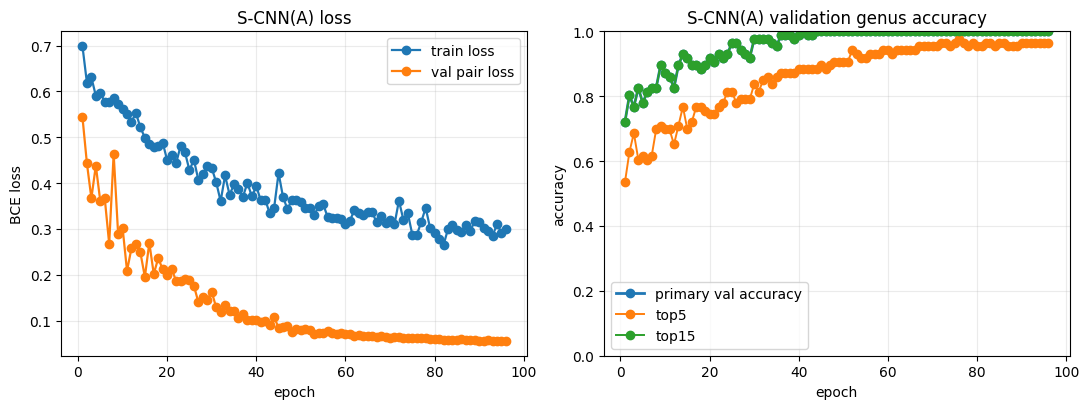

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

history_path = Path('/content/diploma/checkpoints/scnn_genus_vgg16_history.csv')
if not history_path.exists():
    raise FileNotFoundError(f'Missing training history: {history_path}. Run the full S-CNN(A) training cell first.')

history = pd.read_csv(history_path)
for column in history.columns:
    if column != 'val_score_mode':
        history[column] = pd.to_numeric(history[column], errors='coerce')
display(history.tail(10))

epochs = history['epoch']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(epochs, history['train_loss'], marker='o', linewidth=1.6, label='train loss')
if 'val_pair_loss' in history.columns and history['val_pair_loss'].notna().any():
    axes[0].plot(epochs, history['val_pair_loss'], marker='o', linewidth=1.6, label='val pair loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('BCE loss')
axes[0].set_title('S-CNN(A) loss')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

accuracy_columns = [
    column for column in history.columns
    if column.startswith('val_top') and column.endswith('_genus_accuracy')
]
if 'val_primary_accuracy' in history.columns:
    axes[1].plot(epochs, history['val_primary_accuracy'], marker='o', linewidth=2.0, label='primary val accuracy')
for column in accuracy_columns:
    label = column.replace('val_', '').replace('_genus_accuracy', '')
    axes[1].plot(epochs, history[column], marker='o', linewidth=1.4, label=label)
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1)
axes[1].set_title('S-CNN(A) validation genus accuracy')
axes[1].grid(True, alpha=0.25)
if accuracy_columns or 'val_primary_accuracy' in history.columns:
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No validation columns in history', ha='center', va='center')

fig.tight_layout()
drive_dir = Path('/content/drive/MyDrive/diploma_diagnostics/training_curves')
out_dir = drive_dir if drive_dir.parent.exists() else history_path.parent
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'scnn_genus_vgg16_training_history.png'
fig.savefig(out_path, dpi=180)
print('Saved:', out_path)
plt.show()


## 7. Save VGG16 Genus Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [5]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=vgg16
STAGE=genus
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


missing optional artifact: checkpoints/scnn_genus_vgg16.pt
saved vgg16 genus checkpoints to /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/genus_20260524T123445Z_24567
total 513M
-rw------- 1 root root    8 May 24 12:34 commit.txt
-rw------- 1 root root   21 May 24 12:34 saved_at_utc.txt
-rw------- 1 root root 513M May 24 12:34 scnn_genus_vgg16_best.pt
-rw------- 1 root root 5.4K May 24 12:34 scnn_genus_vgg16_history.csv
-rw------- 1 root root  178 May 24 12:34 sha256sums.txt


## 8. Evaluate Full VGG16 `S-CNN (A)`


In [7]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
python -u -m plant_classifier.training.eval_genus_cli   --config configs/leafscan_paper60_training.yaml   --query-config configs/leafscan_test.yaml   --checkpoint checkpoints/scnn_genus_vgg16_best.pt   --max-species 0   --references-per-genus 6   --reference-level genus   --reference-seed "$REFERENCE_SEED"   --reference-split train   --score-mode comparator   --top-k 5 15 30 50


using reference subset: 360 images from 60 species
references=258 queries=221 top_k=[5, 15, 30, 50] score_mode=comparator reference_seed=42
top5_genus_accuracy=0.371 (82/221)
top15_genus_accuracy=0.575 (127/221)
top30_genus_accuracy=0.742 (164/221)
top50_genus_accuracy=0.828 (183/221)
query genus distribution: {'Acer': 27, 'Ruscus': 25, 'Fraxinus': 17, 'Viburnum': 12, 'Quercus': 11, 'Ginkgo': 9, 'Hedera': 9, 'Castanea': 9, 'Populus': 8, 'Lippia': 7}
reference genus distribution: {'Acer': 6, 'Ailanthus': 6, 'Alnus': 6, 'Artemisia': 6, 'Asplenium': 6, 'Atriplex': 6, 'Betula': 6, 'Broussonetia': 6, 'Buddleja': 6, 'Carpinus': 6}
reference pool species per genus: {'Acer': 6, 'Quercus': 4, 'Fraxinus': 3, 'Populus': 3, 'Prunus': 3, 'Crataegus': 2, 'Tilia': 2, 'Viburnum': 2, 'Ailanthus': 1, 'Alnus': 1}
genus reference species coverage: {'Acer': '6/6', 'Quercus': '4/4', 'Fraxinus': '3/3', 'Populus': '3/3', 'Prunus': '3/3', 'Crataegus': '2/2', 'Tilia': '2/2', 'Viburnum': '2/2', 'Ailanthus': '1/1

## 8a. Diagnostic VGG16 `S-CNN (A)` L1 Ranking

The paper-aligned score is the learned comparator above. This block keeps the same references and checkpoint, but ranks by raw L1 embedding distance to diagnose whether the comparator head is hurting retrieval.


In [11]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
python -u -m plant_classifier.training.eval_genus_cli   --config configs/leafscan_paper60_training.yaml   --query-config configs/leafscan_test.yaml   --checkpoint checkpoints/scnn_genus_vgg16_best.pt   --max-species 0   --references-per-genus 6   --reference-level genus   --reference-seed "$REFERENCE_SEED"   --reference-split train   --score-mode l1   --top-k 5 15 30 50


using reference subset: 360 images from 60 species
references=258 queries=221 top_k=[5, 15, 30, 50] score_mode=l1 reference_seed=42
top5_genus_accuracy=0.597 (132/221)
top15_genus_accuracy=0.751 (166/221)
top30_genus_accuracy=0.814 (180/221)
top50_genus_accuracy=0.855 (189/221)
query genus distribution: {'Acer': 27, 'Ruscus': 25, 'Fraxinus': 17, 'Viburnum': 12, 'Quercus': 11, 'Ginkgo': 9, 'Hedera': 9, 'Castanea': 9, 'Populus': 8, 'Lippia': 7}
reference genus distribution: {'Acer': 6, 'Ailanthus': 6, 'Alnus': 6, 'Artemisia': 6, 'Asplenium': 6, 'Atriplex': 6, 'Betula': 6, 'Broussonetia': 6, 'Buddleja': 6, 'Carpinus': 6}
reference pool species per genus: {'Acer': 6, 'Quercus': 4, 'Fraxinus': 3, 'Populus': 3, 'Prunus': 3, 'Crataegus': 2, 'Tilia': 2, 'Viburnum': 2, 'Ailanthus': 1, 'Alnus': 1}
genus reference species coverage: {'Acer': '6/6', 'Quercus': '4/4', 'Fraxinus': '3/3', 'Populus': '3/3', 'Prunus': '3/3', 'Crataegus': '2/2', 'Tilia': '2/2', 'Viburnum': '2/2', 'Ailanthus': '1/1', 'Aln

## 9. Full VGG16 Train `S-CNN (B)` Species

Run this after VGG16 `S-CNN (A)` has a reasonable genus retrieval result.


In [ ]:
!set -euo pipefail
!export PYTHONUNBUFFERED=1
!cd /content/diploma
!python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_training.yaml   --stage species   --output checkpoints/scnn_species_vgg16.pt


using subset: 360 images from 60 species
training split=train records=360
building model backbone=vgg16 pretrained=True
model ready
training device=cuda
epoch=1 sampled_pairs=2000 sampling=pair_uniform batch_size=32 device=cuda
epoch=1 batch=5/63 running_loss=0.7392
epoch=1 batch=10/63 running_loss=0.7401
epoch=1 batch=15/63 running_loss=0.7231
epoch=1 batch=20/63 running_loss=0.7113
epoch=1 batch=25/63 running_loss=0.7066
epoch=1 batch=30/63 running_loss=0.7009
epoch=1 batch=35/63 running_loss=0.6959
epoch=1 batch=40/63 running_loss=0.6944
epoch=1 batch=45/63 running_loss=0.6984
epoch=1 batch=50/63 running_loss=0.6975
epoch=1 batch=55/63 running_loss=0.6937
epoch=1 batch=60/63 running_loss=0.6897
epoch=1 batch=63/63 running_loss=0.6881
epoch=1 loss=0.6881 best_loss=0.6881 time=165.5s best
epoch=2 sampled_pairs=2000 sampling=pair_uniform batch_size=32 device=cuda
epoch=2 batch=5/63 running_loss=0.6660
epoch=2 batch=10/63 running_loss=0.6585
epoch=2 batch=15/63 running_loss=0.6669
epoch

## 10. Save VGG16 Species Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=vgg16
STAGE=species
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


saved vgg16 species checkpoints to /content/drive/MyDrive/diploma_checkpoints/leafscan_vgg16/species_20260521T000608Z_7744
total 1.1G
-rw------- 1 root root    8 May 21 00:06 commit.txt
-rw------- 1 root root   21 May 21 00:06 saved_at_utc.txt
-rw------- 1 root root 513M May 21 00:06 scnn_species_vgg16_best.pt
-rw------- 1 root root 513M May 21 00:06 scnn_species_vgg16.pt
-rw------- 1 root root  357 May 21 00:06 sha256sums.txt


## 11. Evaluate Full VGG16 Two-Stage Species Ranking

Evaluates the current local S-CNN(A) genus checkpoint and S-CNN(B) species checkpoint produced by this training run. Diagnostics that load old checkpoints from Google Drive live in separate diagnostic notebooks.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
BASE_OUT="/content/drive/MyDrive/diploma_diagnostics/species_vgg16_$(date -u +%Y%m%dT%H%M%SZ)"
GENUS_CHECKPOINT="checkpoints/scnn_genus_vgg16_best.pt"
SPECIES_CHECKPOINT="checkpoints/scnn_species_vgg16_best.pt"

if [ ! -f "$GENUS_CHECKPOINT" ]; then
  echo "Missing local S-CNN(A) checkpoint: $GENUS_CHECKPOINT" >&2
  echo "Run the VGG16 S-CNN(A) training cell in this notebook first." >&2
  exit 3
fi
if [ ! -f "$SPECIES_CHECKPOINT" ]; then
  echo "Missing local S-CNN(B) checkpoint: $SPECIES_CHECKPOINT" >&2
  echo "Run the VGG16 S-CNN(B) training cell in this notebook first." >&2
  exit 4
fi

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE_OUT"
sha256sum "$GENUS_CHECKPOINT"
sha256sum "$SPECIES_CHECKPOINT"

for PROFILE in best_s best_top5; do
  if [ "$PROFILE" = best_s ]; then
    GENUS_CANDIDATES=5
  else
    GENUS_CANDIDATES=15
  fi
  OUT_DIR="${BASE_OUT}_${PROFILE}"
  echo "=== ${PROFILE}: genus_candidates=${GENUS_CANDIDATES}, l1/l1/mean ==="
  python -u -m plant_classifier.training.eval_species_cli \
    --config configs/leafscan_paper60_training.yaml \
    --query-config configs/leafscan_test.yaml \
    --genus-checkpoint "$GENUS_CHECKPOINT" \
    --species-checkpoint "$SPECIES_CHECKPOINT" \
    --genus-references-per-genus 6 \
    --references-per-species 6 \
    --genus-candidates "$GENUS_CANDIDATES" \
    --reference-seed "$REFERENCE_SEED" \
    --reference-split train \
    --genus-score-mode l1 \
    --species-score-mode l1 \
    --species-aggregation mean \
    --output-dir "$OUT_DIR" \
    --top-k 1 3 5
  ls -lh "$OUT_DIR"
done


## 12. Full VGG16 Baseline Species Classifier

Trains a plain supervised VGG16 classifier on the same six-shot paper60 LeafScan training subset as the S-CNN method. This is the comparison baseline without S-CNN pairs and without the two-stage hierarchy.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.classifier_cli \
  --config configs/leafscan_paper60_vgg16_baseline.yaml \
  --output checkpoints/vgg16_species_classifier.pt


## 13. Save VGG16 Baseline Classifier Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous classifier checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=vgg16
STAGE=species_classifier
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/vgg16_species_classifier.pt" "checkpoints/vgg16_species_classifier_best.pt" "checkpoints/vgg16_species_classifier_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional checkpoint: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/vgg16_species_classifier_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/vgg16_species_classifier_history.csv" --output-dir "$DEST" --best-name "vgg16_species_classifier_best.pt" --final-name "vgg16_species_classifier.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


## 14. Evaluate VGG16 Baseline Species Classifier

Evaluates both best and final supervised VGG16 checkpoints on the official LeafScan test set.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

for checkpoint in \
  checkpoints/vgg16_species_classifier_best.pt \
  checkpoints/vgg16_species_classifier.pt; do
  echo "=== evaluating ${checkpoint} ==="
  name="$(basename "$checkpoint" .pt)"
  OUT_DIR="/content/drive/MyDrive/diploma_diagnostics/classifier_${name}_$(date -u +%Y%m%dT%H%M%SZ)"
  python -u -m plant_classifier.training.eval_classifier_cli \
    --config configs/leafscan_paper60_vgg16_baseline.yaml \
    --query-config configs/leafscan_test.yaml \
    --checkpoint "$checkpoint" \
    --output-dir "$OUT_DIR" \
    --top-k 1 3 5
  ls -lh "$OUT_DIR"
done


## 15. Smoke Train EfficientNet-B3

Checks both genus and species stages on a small subset before the full EfficientNet-B3 run.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/smoke_training_efficientnet_b3.yaml   --stage genus   --output checkpoints/smoke_scnn_genus_efficientnet_b3.pt
python -u -m plant_classifier.training.cli   --config configs/smoke_training_efficientnet_b3.yaml   --stage species   --output checkpoints/smoke_scnn_species_efficientnet_b3.pt


## 16. Smoke Evaluate EfficientNet-B3 `S-CNN (A)` On Validation Split


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.eval_genus_cli   --config configs/smoke_training_efficientnet_b3.yaml   --checkpoint checkpoints/smoke_scnn_genus_efficientnet_b3.pt   --max-species 40   --references-per-genus 2   --queries-per-genus 2   --top-k 5


## 17. Full EfficientNet-B3 Train `S-CNN (A)` Genus


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_efficientnet_b3.yaml   --stage genus   --output checkpoints/scnn_genus_efficientnet_b3.pt


## 18. Save EfficientNet-B3 Genus Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=efficientnet_b3
STAGE=genus
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


## 19. Evaluate Full EfficientNet-B3 `S-CNN (A)`


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
python -u -m plant_classifier.training.eval_genus_cli \
  --config configs/leafscan_paper60_efficientnet_b3.yaml \
  --query-config configs/leafscan_test.yaml \
  --checkpoint checkpoints/scnn_genus_efficientnet_b3_best.pt \
  --max-species 0 \
  --references-per-genus 6 \
  --reference-level genus \
  --reference-seed "$REFERENCE_SEED" \
  --reference-split train \
  --score-mode comparator \
  --top-k 5 15 30 50


## 20. Full EfficientNet-B3 Train `S-CNN (B)` Species


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_efficientnet_b3.yaml   --stage species   --output checkpoints/scnn_species_efficientnet_b3.pt


## 21. Save EfficientNet-B3 Species Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=efficientnet_b3
STAGE=species
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


## 22. Evaluate Full EfficientNet-B3 Two-Stage Species Ranking


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
OUT_DIR="/content/drive/MyDrive/diploma_diagnostics/species_efficientnet_b3_$(date -u +%Y%m%dT%H%M%SZ)"
python -u -m plant_classifier.training.eval_species_cli \
  --config configs/leafscan_paper60_efficientnet_b3.yaml \
  --query-config configs/leafscan_test.yaml \
  --genus-checkpoint checkpoints/scnn_genus_efficientnet_b3_best.pt \
  --species-checkpoint checkpoints/scnn_species_efficientnet_b3_best.pt \
  --genus-references-per-genus 6 \
  --references-per-species 6 \
  --genus-candidates 30 \
  --reference-seed "$REFERENCE_SEED" \
  --reference-split train \
  --genus-score-mode l1 \
  --species-score-mode comparator \
  --species-aggregation max \
  --output-dir "$OUT_DIR" \
  --top-k 1 3 5
ls -lh "$OUT_DIR"



## 23. Smoke Train MobileNetV3-Large

Checks both genus and species stages on a small subset before the full MobileNetV3-Large run.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/smoke_training_mobilenet_v3_large.yaml   --stage genus   --output checkpoints/smoke_scnn_genus_mobilenet_v3_large.pt
python -u -m plant_classifier.training.cli   --config configs/smoke_training_mobilenet_v3_large.yaml   --stage species   --output checkpoints/smoke_scnn_species_mobilenet_v3_large.pt


## 24. Smoke Evaluate MobileNetV3-Large `S-CNN (A)` On Validation Split


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.eval_genus_cli   --config configs/smoke_training_mobilenet_v3_large.yaml   --checkpoint checkpoints/smoke_scnn_genus_mobilenet_v3_large.pt   --max-species 40   --references-per-genus 2   --queries-per-genus 2   --top-k 5


## 25. Full MobileNetV3-Large Train `S-CNN (A)` Genus


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_mobilenet_v3_large.yaml   --stage genus   --output checkpoints/scnn_genus_mobilenet_v3_large.pt


## 26. Save MobileNetV3-Large Genus Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=mobilenet_v3_large
STAGE=genus
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


## 27. Evaluate Full MobileNetV3-Large `S-CNN (A)`


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
python -u -m plant_classifier.training.eval_genus_cli \
  --config configs/leafscan_paper60_mobilenet_v3_large.yaml \
  --query-config configs/leafscan_test.yaml \
  --checkpoint checkpoints/scnn_genus_mobilenet_v3_large_best.pt \
  --max-species 0 \
  --references-per-genus 6 \
  --reference-level genus \
  --reference-seed "$REFERENCE_SEED" \
  --reference-split train \
  --score-mode comparator \
  --top-k 5 15 30 50


## 28. Full MobileNetV3-Large Train `S-CNN (B)` Species


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.cli   --config configs/leafscan_paper60_mobilenet_v3_large.yaml   --stage species   --output checkpoints/scnn_species_mobilenet_v3_large.pt


## 29. Save MobileNetV3-Large Species Checkpoints To Google Drive

Creates a new timestamped folder on every run, so previous checkpoint saves are preserved.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma

MODEL=mobilenet_v3_large
STAGE=species
BASE="/content/drive/MyDrive/diploma_checkpoints/leafscan_${MODEL}"
SAVE_ID="${STAGE}_$(date -u +%Y%m%dT%H%M%SZ)_${RANDOM}"
DEST="${BASE}/${SAVE_ID}"

test -d /content/drive/MyDrive || { echo "Google Drive is not mounted" >&2; exit 2; }
mkdir -p "$BASE"
mkdir "$DEST"

found=0
for file in "checkpoints/scnn_${STAGE}_${MODEL}.pt" "checkpoints/scnn_${STAGE}_${MODEL}_best.pt" "checkpoints/scnn_${STAGE}_${MODEL}_history.csv"; do
  if [ -f "$file" ]; then
    cp "$file" "$DEST/$(basename "$file")"
    if [[ "$file" == *.pt ]]; then
      found=1
    fi
  else
    echo "missing optional artifact: $file"
  fi
done

if [ "$found" -eq 0 ]; then
  echo "No ${STAGE} ${MODEL} checkpoints found to save" >&2
  exit 3
fi

date -u +%Y-%m-%dT%H:%M:%SZ > "$DEST/saved_at_utc.txt"
(git rev-parse --short HEAD || echo unknown) > "$DEST/commit.txt"
sha256sum "$DEST"/*.pt > "$DEST/sha256sums.txt"
if [ -f "$DEST/scnn_${STAGE}_${MODEL}_history.csv" ]; then
  python scripts/write_checkpoint_metrics.py --history "$DEST/scnn_${STAGE}_${MODEL}_history.csv" --output-dir "$DEST" --best-name "scnn_${STAGE}_${MODEL}_best.pt" --final-name "scnn_${STAGE}_${MODEL}.pt"
fi
echo "saved ${MODEL} ${STAGE} checkpoints to $DEST"
ls -lh "$DEST"


## 30. Evaluate Full MobileNetV3-Large Two-Stage Species Ranking


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
REFERENCE_SEED=42
OUT_DIR="/content/drive/MyDrive/diploma_diagnostics/species_mobilenet_v3_large_$(date -u +%Y%m%dT%H%M%SZ)"
python -u -m plant_classifier.training.eval_species_cli \
  --config configs/leafscan_paper60_mobilenet_v3_large.yaml \
  --query-config configs/leafscan_test.yaml \
  --genus-checkpoint checkpoints/scnn_genus_mobilenet_v3_large_best.pt \
  --species-checkpoint checkpoints/scnn_species_mobilenet_v3_large_best.pt \
  --genus-references-per-genus 6 \
  --references-per-species 6 \
  --genus-candidates 30 \
  --reference-seed "$REFERENCE_SEED" \
  --reference-split train \
  --genus-score-mode l1 \
  --species-score-mode comparator \
  --species-aggregation max \
  --output-dir "$OUT_DIR" \
  --top-k 1 3 5
ls -lh "$OUT_DIR"



## 31. Sync Checkpoints To Google Drive

Old Drive checkpoints are removed unless their name contains `_best`. Local `*_best` files are copied to Drive as regular checkpoint names, so Drive `*_best` files can mean best-across-all-runs.


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python scripts/sync_checkpoints_to_drive.py \
  --source checkpoints \
  --dest /content/drive/MyDrive/diploma_checkpoints \
  --keep-token _best
ls -lh /content/drive/MyDrive/diploma_checkpoints


removed old checkpoints: 2
copied checkpoints: 6
destination: /content/drive/MyDrive/diploma_checkpoints
total 1.6G
drwx------  3 root root 4.0K May 20 14:45 leafscan_efficientnet_b3
drwx------ 10 root root 4.0K May 21 00:06 leafscan_vgg16
-rw-------  1 root root 513M May 20 22:20 scnn_genus_vgg16.pt
-rw-------  1 root root 513M May 21 00:04 scnn_species_vgg16.pt
-rw-------  1 root root 513M May 20 20:25 smoke_scnn_genus_vgg16.pt


## 32. Build VGG16 Reference Index For Desktop Inference


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python -u -m plant_classifier.training.build_index_cli \
  --config configs/leafscan_paper60_training.yaml \
  --genus-checkpoint checkpoints/scnn_genus_vgg16_best.pt \
  --species-checkpoint checkpoints/scnn_species_vgg16_best.pt \
  --output checkpoints/reference_index_leafscan_vgg16.pt
ls -lh checkpoints


using subset: 360 images from 60 species
saved 258 genus and 360 species reference embeddings to checkpoints/reference_index_leafscan_vgg16.pt
total 3.1G
-rw-r--r-- 1 root root  20M May 21 00:11 reference_index_leafscan_vgg16.pt
-rw------- 1 root root 513M May 20 22:20 scnn_genus_vgg16_best.pt
-rw-r--r-- 1 root root 513M May 20 22:31 scnn_genus_vgg16.pt
-rw-r--r-- 1 root root 513M May 21 00:04 scnn_species_vgg16_best.pt
-rw-r--r-- 1 root root 513M May 21 00:06 scnn_species_vgg16.pt
-rw-r--r-- 1 root root 513M May 20 20:25 smoke_scnn_genus_vgg16_best.pt
-rw-r--r-- 1 root root 513M May 20 20:25 smoke_scnn_genus_vgg16.pt


## 33. Final Sync To Google Drive


In [ ]:
%%bash
set -euo pipefail
export PYTHONUNBUFFERED=1
cd /content/diploma
python scripts/sync_checkpoints_to_drive.py \
  --source checkpoints \
  --dest /content/drive/MyDrive/diploma_checkpoints \
  --keep-token _best
ls -lh /content/drive/MyDrive/diploma_checkpoints


removed old checkpoints: 3
copied checkpoints: 7
destination: /content/drive/MyDrive/diploma_checkpoints
total 1.6G
drwx------  3 root root 4.0K May 20 14:45 leafscan_efficientnet_b3
drwx------ 10 root root 4.0K May 21 00:06 leafscan_vgg16
-rw-------  1 root root  20M May 21 00:11 reference_index_leafscan_vgg16.pt
-rw-------  1 root root 513M May 20 22:20 scnn_genus_vgg16.pt
-rw-------  1 root root 513M May 21 00:04 scnn_species_vgg16.pt
-rw-------  1 root root 513M May 20 20:25 smoke_scnn_genus_vgg16.pt
